# Análisis personal — MedData Challenge

**Integrante:** Jesus (`jesus12ga`)

Este notebook trabaja únicamente con reglas matemáticas y métodos estadísticos. No usa machine learning. El notebook de Cornelio es independiente y no debe editarse.

In [1]:
from pathlib import Path
import os
import runpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Permite ejecutar desde VS Code/Jupyter aunque el directorio inicial cambie.
ROOT = Path.cwd()
for candidate in (ROOT, *ROOT.parents):
    if (candidate / "data" / "diabetes_012_health_indicators_BRFSS2015.csv").exists():
        ROOT = candidate
        break
os.chdir(ROOT)
OUTPUTS = ROOT / "outputs"
OUTPUTS.mkdir(exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid")
print("Raíz:", ROOT)
print("Entorno estadístico listo; sin sklearn ni modelos de ML.")

Raíz: C:\Users\jeyme\OneDrive - Universidad Tecnológica de Panamá\Escritorio\datathon-meddata
Entorno estadístico listo; sin sklearn ni modelos de ML.


## 1. Datos e inconsistencias

El reto pide identificar inconsistencias antes de construir el score.

In [2]:
RUTA = ROOT / "data" / "diabetes_012_health_indicators_BRFSS2015.csv"
raw = pd.read_csv(RUTA)
print("Shape original:", raw.shape)
print("Distribución del target (%):")
print((raw["Diabetes_012"].value_counts(normalize=True).sort_index() * 100).round(2))

inconsistencias = pd.Series({
    "duplicados exactos": int(raw.duplicated().sum()),
    "BMI fuera de 12-60": int(((raw.BMI < 12) | (raw.BMI > 60)).sum()),
    "sin seguro y sin costo": int(((raw.AnyHealthcare == 0) & (raw.NoDocbcCost == 0)).sum()),
    "días de salud inválidos": int(((raw.MentHlth > 30) | (raw.PhysHlth > 30)).sum()),
})
print("\nInconsistencias detectadas:")
print(inconsistencias.to_string())

Shape original: (253680, 22)
Distribución del target (%):
Diabetes_012
0.0    84.24
1.0     1.83
2.0    13.93
Name: proportion, dtype: float64

Inconsistencias detectadas:
duplicados exactos         23899
BMI fuera de 12-60           805
sin seguro y sin costo      7838
días de salud inválidos        0


## 2. Score estadístico del equipo

Se reutiliza el motor de puntuación de Cornelio, basado en prevalencias, odds ratios y aritmética. La prediabetes se excluye del ajuste y el score clasifica diabetes confirmada.

In [3]:
score_ns = runpy.run_path(str(ROOT / "src" / "score_diabetes.py"))
score_df = score_ns["df"]
tabla = pd.read_csv(OUTPUTS / "tabla_puntuacion.csv")
grupos = score_ns["grupos"]
CORTE_DERIVACION = score_ns["CORTE_DERIVACION"]
print("Filas finales:", len(score_df))
print("Corte de derivación:", CORTE_DERIVACION)
print("AUC (Mann-Whitney):", round(float(score_ns["auc"]), 3))
print("Sensibilidad:", round(float(score_ns["sens"]) * 100, 1), "%")
print("Especificidad:", round(float(score_ns["esp"]) * 100, 1), "%")
print("\nPrevalencia por nivel de riesgo:")
print(grupos.to_string())

Filas finales: 224364
Corte de derivación: 7
AUC (Mann-Whitney): 0.798
Sensibilidad: 85.5 %
Especificidad: 58.5 %

Prevalencia por nivel de riesgo:
               n  casos  prev_%
RIESGO                         
Bajo      115913   5059     4.4
Moderado   56450  10103    17.9
Alto       36137  11965    33.1
Muy alto   15864   7799    49.2


## 3. Gráfica estrella: el score separa el riesgo

La prevalencia aumenta de forma monotónica entre los niveles de riesgo.

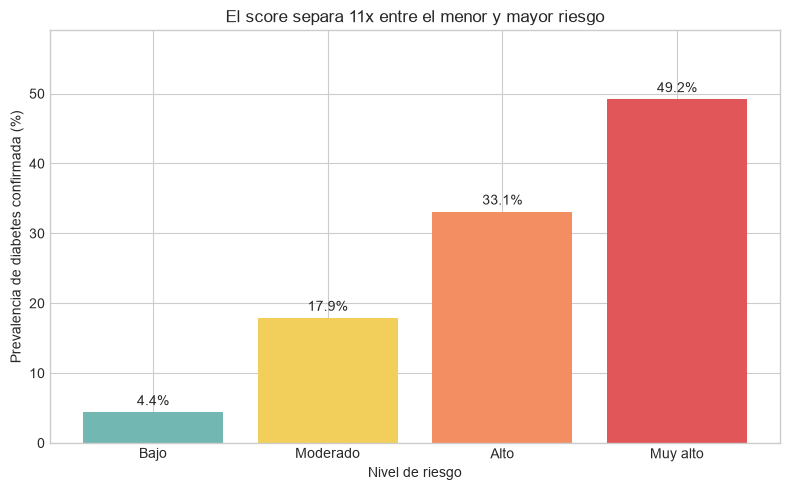

In [4]:
orden = ["Bajo", "Moderado", "Alto", "Muy alto"]
prevalencias = grupos.loc[orden, "prev_%"]
ratio = prevalencias.iloc[-1] / prevalencias.iloc[0]
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(prevalencias.index, prevalencias.values, color=["#72b7b2", "#f2cf5b", "#f28e62", "#e15759"])
ax.set_title(f"El score separa {ratio:.0f}x entre el menor y mayor riesgo")
ax.set_xlabel("Nivel de riesgo")
ax.set_ylabel("Prevalencia de diabetes confirmada (%)")
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)
ax.set_ylim(0, max(prevalencias) * 1.2)
plt.tight_layout()
fig.savefig(OUTPUTS / "prevalencia_por_riesgo.png", dpi=110, bbox_inches="tight")
plt.show()

## 4. Distribución del score y cortes

Los cortes 6, 10 y 13 separan Bajo, Moderado, Alto y Muy alto.

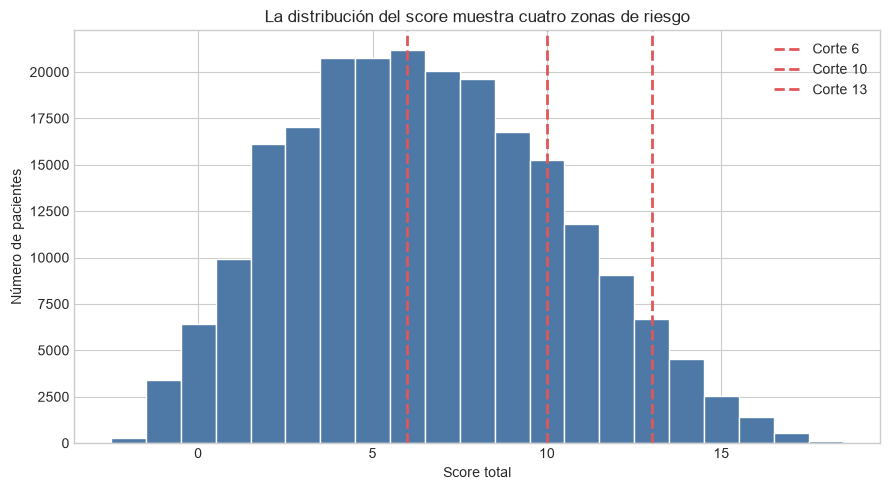

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(score_df["SCORE"], bins=range(int(score_df["SCORE"].min()), int(score_df["SCORE"].max()) + 2), color="#4e79a7", edgecolor="white", align="left")
for corte in [6, 10, 13]:
    ax.axvline(corte, color="#e15759", linestyle="--", linewidth=2, label=f"Corte {corte}")
ax.set_title("La distribución del score muestra cuatro zonas de riesgo")
ax.set_xlabel("Score total")
ax.set_ylabel("Número de pacientes")
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUTS / "distribucion_score.png", dpi=110, bbox_inches="tight")
plt.show()

## 5. Qué factores aportan más puntos

Se lee la tabla de puntuación generada por el motor del equipo y se ordenan los factores por puntos acumulados.

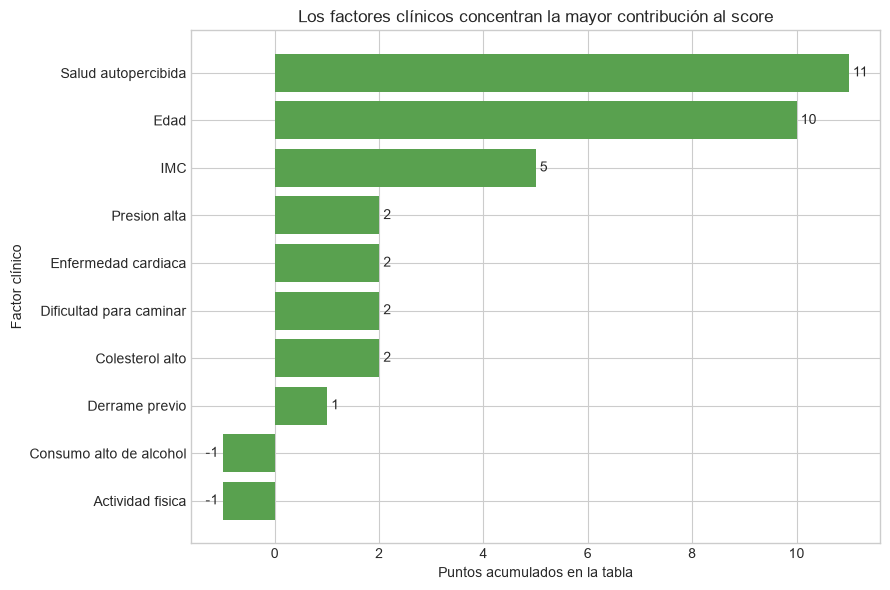

In [6]:
puntos_factor = (tabla.groupby("nombre", as_index=False)["puntos"].sum()
                 .sort_values("puntos", ascending=True))
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(puntos_factor["nombre"], puntos_factor["puntos"], color="#59a14f")
ax.set_title("Los factores clínicos concentran la mayor contribución al score")
ax.set_xlabel("Puntos acumulados en la tabla")
ax.set_ylabel("Factor clínico")
ax.bar_label(ax.containers[0], padding=3)
plt.tight_layout()
fig.savefig(OUTPUTS / "puntos_por_factor.png", dpi=110, bbox_inches="tight")
plt.show()

## Hallazgos y límites

- La prevalencia debe aumentar entre Bajo, Moderado, Alto y Muy alto; citar las cifras de la tabla y la primera gráfica.
- El score es una herramienta de estratificación y derivación, no un diagnóstico.
- Las asociaciones descriptivas no demuestran causalidad.
- La validación debe comunicarse junto con sus supuestos y con la revisión clínica del equipo.